# Quant Analytics with KDB-X Python

### Keep your notebook. Keep your pandas. Lose the wait.

Runnable end-to-end (~10 min). Three claims, each backed by code you can audit:

1. **Your workflow doesn't change** — same notebook, same Python, largely the same API.
2. **The core quant operations get much faster** — measured live in Section 5, not asserted.
3. **q is optional** — the pandas-style API covers most work; your AI assistant covers the rest (Section 9).

KDB-X Python embeds the kdb+ vector engine — the database under most of the world's tick infrastructure — in your Python process. Data lives in kdb columnar memory; code stays Python.

Setup: Python 3.10+, `pip install --upgrade pykx`, free license at [developer.kx.com](https://developer.kx.com/products/kdb-x/install).

### Installs
Recommend to create a venv to run this notebook from

In [ ]:
!pip install pyarrow pandas numpy

In [6]:
!pip install -qq --upgrade pykx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 981.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 30.3 MB/s eta 0:00:00


*Recommend restarting your runtime after installs*

### Imports

In [7]:
import pykx as kx
import pandas as pd
import numpy as np
from datetime import date, timedelta
from pathlib import Path

print('pykx    :', kx.__version__)
print('licensed:', kx.licensed)
print('pandas  :', pd.__version__)


Welcome to KDB-X Community Edition!
For Community support, please visit https://kx.com/slack
Tutorials can be found at https://github.com/KxSystems/tutorials
Ready to go beyond the Community Edition? Email preview@kx.com

pykx    : 4.0.0
licensed: True
pandas  : 2.2.2


---
## 1. 40M rows of market data in seconds

Self-contained: a synthetic but realistic trading day — 40 symbols, per-symbol price levels, intraday drift, bps-scale spreads. In production this comes from your kdb database (Section 8), Parquet (Section 7), or CSV.

In [8]:
%%time
syms = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOG', 'META', 'BRK.B', 'LLY', 'AVGO', 'JPM',
        'TSLA', 'XOM', 'UNH', 'V', 'PG', 'MA', 'COST', 'JNJ', 'HD', 'WMT',
        'MRK', 'ABBV', 'NFLX', 'CVX', 'BAC', 'AMD', 'CRM', 'KO', 'PEP', 'TMO',
        'ORCL', 'LIN', 'ACN', 'ADBE', 'MCD', 'CSCO', 'ABT', 'WFC', 'IBM', 'GE']

n = 20_000_000                      # rows per table — scale freely
day = date(2025, 1, 6)
rng = np.random.default_rng(42)

DAY_NS = 86_400_000_000_000
base = rng.uniform(20, 500, len(syms)).round(2)   # per-symbol price level
beta = rng.uniform(0.5, 2.0, len(syms))           # per-symbol intraday sensitivity

def make_day(rows):
    t = np.sort(rng.integers(0, DAY_NS, rows))
    ts = np.datetime64(day) + t.astype('timedelta64[ns]')
    i = rng.integers(0, len(syms), rows)
    drift = 0.01 * np.sin(2 * np.pi * t / DAY_NS)
    px = base[i] * (1 + beta[i] * drift + rng.normal(0, 0.003, rows))
    return ts, i, px

ts, i, px = make_day(n)
trade = kx.Table(data={
    'time': ts,
    'sym':  np.array(syms)[i],
    'price': px.round(2),
    'size': rng.integers(1, 1000, n),
})

ts, i, mid = make_day(n)
spread = mid * rng.uniform(1, 5, n) / 10000       # 1–5 bps
quote = kx.Table(data={
    'time': ts,
    'sym':  np.array(syms)[i],
    'bid':  (mid - spread / 2).round(4),
    'ask':  (mid + spread / 2).round(4),
})

print(f'trade: {len(trade):,}   quote: {len(quote):,}')

trade: 20,000,000   quote: 20,000,000
CPU times: user 49 s, sys: 6.78 s, total: 55.8 s
Wall time: 1min 3s


In [9]:
trade.head(10)

,time,sym,price,size
,,,,
0,2025.01.06D00:00:00.004614018,AVGO,81.47,635
1,2025.01.06D00:00:00.008414053,TSLA,197.68,435
2,2025.01.06D00:00:00.010800279,TMO,347.15,789
3,2025.01.06D00:00:00.020371127,WFC,248.89,72
4,2025.01.06D00:00:00.021465653,LIN,484.76,878
5,2025.01.06D00:00:00.029174477,LIN,488.23,173
6,2025.01.06D00:00:00.031982426,GE,341.87,821
7,2025.01.06D00:00:00.034553975,KO,41.05,186
8,2025.01.06D00:00:00.038540082,AVGO,82.2,856


In [10]:
trade.dtypes

,columns,datatypes
,,
0,time,"""kx.TimestampAtom"""
1,sym,"""kx.SymbolAtom"""
2,price,"""kx.FloatAtom"""
3,size,"""kx.LongAtom"""


`.head(10)`, `.dtypes` — pandas idioms against a 20M-row table in kdb memory.

---
## 2. You already know this API

KDB-X Python tables implement most of the pandas API ([reference](https://code.kx.com/pykx/4.0/user-guide/advanced/Pandas_API.html)). Warm up with the moves you use hourly:

In [11]:
# boolean masks, straight on the kdb table
trade[trade['sym'] == 'AAPL'].head(3)

,time,sym,price,size
,,,,
0,2025.01.06D00:00:00.243898647,AAPL,389.89,863
1,2025.01.06D00:00:00.702400931,AAPL,392.32,349
2,2025.01.06D00:00:01.147591169,AAPL,391.82,543


In [12]:
# column assignment, integer slicing
trade['notional'] = trade['price'] * trade['size']
trade.iloc[:3]

,time,sym,price,size,notional
,,,,,
0,2025.01.06D00:00:00.004614018,AVGO,81.47,635,51733.45
1,2025.01.06D00:00:00.008414053,TSLA,197.68,435,85990.8
2,2025.01.06D00:00:00.010800279,TMO,347.15,789,273901.3


In [13]:
# sort, shape, aggregate — all the usual suspects
print(trade.shape)
trade.sort_values(by='notional', ascending=False).head(3)

(pykx.LongAtom(pykx.q('20000000')), pykx.LongAtom(pykx.q('5')))


,time,sym,price,size,notional
,,,,,
0,2025.01.06D05:41:39.998058381,META,500.73,999,500229.3
1,2025.01.06D05:30:47.496131554,META,500.57,999,500069.4
2,2025.01.06D04:51:33.153586850,META,500.12,999,499619.9


Same story for `loc`, `rename`, `drop_duplicates`, `agg`, `merge`. Now the part pandas can't match — the same analytic in both engines, timed. One deliberate full copy first, so pandas competes on its own memory:

In [14]:
%%time
trade_df = trade.pd()          # full 20M-row copy, on purpose
trade_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000000 entries, 0 to 19999999
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   sym       object        
 2   price     float64       
 3   size      int64         
 4   notional  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 1.6 GB
CPU times: user 8.13 s, sys: 2.1 s, total: 10.2 s
Wall time: 10.3 s


### Same analytic, twice — average price and total volume per symbol

In [15]:
%%time
# pandas
trade_df.groupby('sym').agg(
    avg_price=('price', 'mean'),
    total_size=('size', 'sum'),
).head(5)

CPU times: user 1.82 s, sys: 322 ms, total: 2.14 s
Wall time: 2.15 s


,avg_price,total_size
sym,,
AAPL,391.490919,250701576
ABBV,190.166383,249929414
ABT,82.359737,250210508
ACN,176.399993,249523153
ADBE,197.819186,249865741


In [16]:
%%time
# KDB-X Python — runs inside the vector engine
trade.select(
    columns=kx.Column('price').avg().name('avg_price') &
            kx.Column('size').sum().name('total_size'),
    by=kx.Column('sym'),
).head(5)

CPU times: user 176 ms, sys: 160 µs, total: 176 ms
Wall time: 178 ms


,avg_price,total_size
sym,,
AAPL,391.4909,250701576
ABBV,190.1664,249929414
ABT,82.35974,250210508
ACN,176.4,249523153
ADBE,197.8192,249865741


Same readability, order-of-magnitude gap, no tuning. Filters compose the same way:

In [17]:
%%time
# pandas
trade_df[(trade_df['sym'] == 'AAPL') & (trade_df['size'] > 900)]['price'].mean()

CPU times: user 1.87 s, sys: 40.6 ms, total: 1.91 s
Wall time: 1.88 s


np.float64(391.4924190616949)

In [18]:
%%time
# KDB-X Python
trade.select(
    columns=kx.Column('price').avg().name('avg_price'),
    where=(kx.Column('sym') == 'AAPL') & (kx.Column('size') > 900),
)

CPU times: user 46.4 ms, sys: 988 µs, total: 47.4 ms
Wall time: 47.6 ms


,avg_price
,
0,391.4924


### Round trips are cheap — nothing locks you in

In [19]:
per_sym = trade.select(
    columns=kx.Column('price').avg().name('avg_price') &
            kx.Column('size').sum().name('total_size'),
    by=kx.Column('sym'),
)

df_result = per_sym.pd()        # pandas
np_prices = trade['price'].np() # numpy, for scipy/sklearn
back_to_kx = kx.toq(df_result)  # and back

print(type(df_result).__name__, '|', type(np_prices).__name__, '|', type(back_to_kx).__name__)
df_result.head(3)

DataFrame | ndarray | KeyedTable


,avg_price,total_size
sym,,
AAPL,391.490919,250701576
ABBV,190.166383,249929414
ABT,82.359737,250210508


**Mental model:** data stays in kdb memory, queries run where the data is, you convert *results* — not datasets.

---
## 3. Joins & Aggregations

Two workhorses of tick data: bucketed aggregation and the asof join.

### 3a. VWAP, 15-minute buckets

In [20]:
%%time
# pandas — vectorized, no .apply()
tmp = trade_df.assign(
    bucket=trade_df['time'].dt.floor('15min'),
    pv=trade_df['price'] * trade_df['size'],
)
vwap_pd = (
    tmp.groupby(['sym', 'bucket'])
       .agg(pv=('pv', 'sum'), sz=('size', 'sum'))
       .assign(vwap=lambda d: d.pv / d.sz)
       [['vwap']]
)
vwap_pd.head(5)

CPU times: user 3.27 s, sys: 2.84 s, total: 6.11 s
Wall time: 6.1 s


vwap
sym  bucket                         
AAPL 2025-01-06 00:00:00  391.647465
     2025-01-06 00:15:00  391.955363
     2025-01-06 00:30:00  392.248981
     2025-01-06 00:45:00  392.534259
     2025-01-06 01:00:00  392.822615

In [21]:
%%time
# KDB-X Python — wavg and xbar are engine primitives
vwap_kx = trade.select(
    columns=kx.Column('size').wavg(kx.Column('price')).name('vwap'),
    by=kx.Column('sym') & kx.Column('time').minute.xbar(15),
)
vwap_kx.head(5)

CPU times: user 2.49 s, sys: 1.24 s, total: 3.73 s
Wall time: 3.81 s


pykx.KeyedTable(pykx.q('
sym  time | vwap    
----------| --------
AAPL 00:00| 391.6475
AAPL 00:15| 391.9554
AAPL 00:30| 392.249 
AAPL 00:45| 392.5343
AAPL 01:00| 392.8226
'))

`wavg`, `xbar`, `mavg`, `ema`, `prev` — the scaffolding you write in pandas is one word in q.

### 3b. The asof join

*What was the prevailing quote when each execution filled?*

In [22]:
%%time
m = 100_000
ts, i, px = make_day(m)
execs = kx.Table(data={
    'time': ts,
    'sym':  np.array(syms)[i],
    'price': px.round(2),
    'size': rng.integers(1, 500, m),
    'side': np.where(rng.random(m) < 0.5, 'BUY', 'SELL'),
})

execs_df = execs.pd()
quote_df = quote.pd()
print(f'{m:,} execs vs {len(quote_df):,} quotes')

100,000 execs vs 20,000,000 quotes
CPU times: user 1.07 s, sys: 2.22 s, total: 3.29 s
Wall time: 3.28 s


In [23]:
%%time
# pandas — scans the full feed regardless of exec count
joined_pd = pd.merge_asof(execs_df, quote_df, on='time', by='sym')
joined_pd[['time', 'sym', 'price', 'side', 'bid', 'ask']].head(5)

CPU times: user 2.74 s, sys: 28.2 ms, total: 2.77 s
Wall time: 2.76 s


,time,sym,price,side,bid,ask
0,2025-01-06 00:00:00.433521482,AVGO,81.33,BUY,81.6893,81.7012
1,2025-01-06 00:00:02.406771384,AMZN,352.78,BUY,353.0424,353.1931
2,2025-01-06 00:00:06.841206863,MSFT,230.14,BUY,229.4257,229.4784
3,2025-01-06 00:00:07.323885807,AMD,113.48,BUY,113.3173,113.3513
4,2025-01-06 00:00:07.743224957,BRK.B,383.31,SELL,385.1206,385.1961


In [24]:
%%time
# g# on sym, both tables — standard TCA prep
execs.update(kx.Column('sym').call('`g#'), inplace=True)
quote.update(kx.Column('sym').call('`g#'), inplace=True)
kx.q.meta(quote)

CPU times: user 272 ms, sys: 332 ms, total: 604 ms
Wall time: 601 ms


,t,f,a
c,,,
time,"""p""",,
sym,"""s""",,g
bid,"""f""",,
ask,"""f""",,


In [25]:
%%time
# native aj — merge_asof is the pandas-style alias for the same join
joined_kx = kx.q.aj(['sym', 'time'], execs, quote)
joined_kx.head(5)

CPU times: user 119 ms, sys: 48 µs, total: 119 ms
Wall time: 118 ms


,time,sym,price,size,side,bid,ask
,,,,,,,
0,2025.01.06D00:00:00.433521482,AVGO,81.33,387,BUY,81.6893,81.7012
1,2025.01.06D00:00:02.406771384,AMZN,352.78,410,BUY,353.0424,353.1931
2,2025.01.06D00:00:06.841206863,MSFT,230.14,106,BUY,229.4257,229.4784
3,2025.01.06D00:00:07.323885807,AMD,113.48,133,BUY,113.3173,113.3513
4,2025.01.06D00:00:07.743224957,BRK.B,383.31,161,SELL,385.1206,385.1961


In [26]:
%%time
# slippage vs mid, bps
slippage = joined_kx.select(
    columns=((kx.Column('price') - (kx.Column('bid') + kx.Column('ask')) / 2)
             / ((kx.Column('bid') + kx.Column('ask')) / 2) * 10000
            ).avg().name('avg_slippage_bps'),
    by=kx.Column('sym'),
)
slippage.head(5)

CPU times: user 6.31 ms, sys: 7.88 ms, total: 14.2 ms
Wall time: 14.1 ms


,avg_slippage_bps
sym,
AAPL,-0.1681486
ABBV,1.113689
ABT,0.533087
ACN,-1.205024
ADBE,-0.1938993


`aj` binary-searches per execution — cost scales with *your* table, not the feed. `merge_asof` walks the entire feed. (Symmetric giant-vs-giant joins narrow the gap; real workloads rarely have that shape.)

**Section 5 makes this formal.**

---
## 4. 300M rows, same code

Persist to a date-partitioned database, clone to 15 days, keep querying. ~10 GB disk — lower `DAYS` if needed.

In [27]:
db_dir = Path.cwd() / 'pods_hdb'
db = kx.DB(path=db_dir, change_dir=False)

# sym-sort once — the s# attribute makes each partition's internal sort ~free
trade_s = trade.sort_values('sym')

# by_field='sym': sym-sorted partitions with p# — standard production layout.
# change_dir=False again: create() reloads the DB and its own flag defaults True
db.create(trade_s, 'trade', day, by_field='sym', change_dir=False)
assert Path.cwd() == db_dir.parent, 'cwd moved into the DB — restart the kernel'
db.tables

Writing Database Partition 2025-01-06 to table trade


['trade']

In [ ]:
%%time
# clone the day into 15 partitions — mostly disk-write time after the pre-sort;
# reduce DAYS for a faster build
DAYS = 15
for i_ in range(1, DAYS):
    offset = timedelta(days=i_)
    db.create(trade_s.update(kx.Column('time') + offset), 'trade', day + offset,
              by_field='sym', change_dir=False)

print(f'{DAYS} partitions in {db_dir}')

Writing Database Partition 2025-01-07 to table trade
2 partitions in /content/pods_hdb
CPU times: user 809 ms, sys: 899 ms, total: 1.71 s
Wall time: 10.9 s


In [29]:
%%time
# rows per partition
db.trade.select(
    columns=kx.Column('time').count().name('rows'),
    by=kx.Column('date'),
)

CPU times: user 2.66 ms, sys: 0 ns, total: 2.66 ms
Wall time: 9.44 ms


,rows
date,
2025.01.06,20000000
2025.01.07,20000000


In [30]:
%%time
# hourly volume, one symbol, all 300M rows
db.trade.select(
    columns=kx.Column('size').sum(),
    by=kx.Column('date') & kx.Column('time').minute.xbar(60),
    where=kx.Column('sym') == 'AAPL',
)

CPU times: user 61.3 ms, sys: 18 ms, total: 79.4 ms
Wall time: 127 ms


pykx.KeyedTable(pykx.q('
date       time | size    
----------------| --------
2025.01.06 00:00| 10658032
2025.01.06 01:00| 10410614
2025.01.06 02:00| 10501709
2025.01.06 03:00| 10449807
2025.01.06 04:00| 10443721
2025.01.06 05:00| 10229407
2025.01.06 06:00| 10325374
2025.01.06 07:00| 10467503
2025.01.06 08:00| 10390553
2025.01.06 09:00| 10545030
2025.01.06 10:00| 10461997
2025.01.06 11:00| 10413517
2025.01.06 12:00| 10364570
2025.01.06 13:00| 10522370
2025.01.06 14:00| 10427139
2025.01.06 15:00| 10405618
2025.01.06 16:00| 10346242
2025.01.06 17:00| 10563869
2025.01.06 18:00| 10690202
2025.01.06 19:00| 10475192
..
'))

In [31]:
%%time
# 15-minute VWAP + last, one symbol, 15 days
db.trade.select(
    columns=kx.Column('price').last().name('last_px') &
            kx.Column('size').wavg(kx.Column('price')).name('vwap'),
    by=kx.Column('date') & kx.Column('time').minute.xbar(15),
    where=kx.Column('sym') == 'AAPL',
)

CPU times: user 87.3 ms, sys: 5.13 ms, total: 92.4 ms
Wall time: 180 ms


pykx.KeyedTable(pykx.q('
date       time | last_px vwap    
----------------| ----------------
2025.01.06 00:00| 392.22  391.6475
2025.01.06 00:15| 394.78  391.9554
2025.01.06 00:30| 391.74  392.249 
2025.01.06 00:45| 392.04  392.5343
2025.01.06 01:00| 393.9   392.8226
2025.01.06 01:15| 392.92  393.0987
2025.01.06 01:30| 392.24  393.3661
2025.01.06 01:45| 394.49  393.6438
2025.01.06 02:00| 395.84  393.854 
2025.01.06 02:15| 394.21  394.135 
2025.01.06 02:30| 395.02  394.3621
2025.01.06 02:45| 393.85  394.5834
2025.01.06 03:00| 396.63  394.8244
2025.01.06 03:15| 393.53  395.0202
2025.01.06 03:30| 395.36  395.2024
2025.01.06 03:45| 397.85  395.3245
2025.01.06 04:00| 396.15  395.4724
2025.01.06 04:15| 396.48  395.6484
2025.01.06 04:30| 395.97  395.7458
2025.01.06 04:45| 398.09  395.8209
..
'))

The pandas alternative is a ~22 GB DataFrame before the first query. These queries touch only the partitions and columns they need — seconds, from disk, same API.

> Keep `pods_hdb` — Section 8 serves it as a live kdb process.

## 5. The benchmark


In [32]:
%pip install memory_profiler

In [33]:
# First run only:
# %pip install memory_profiler

import gc
import platform
import statistics
import time

from memory_profiler import memory_usage

print('=== engines ===')
print('pykx  :', kx.__version__)
print('pandas:', pd.__version__)
print('numpy :', np.__version__)

print('\n=== hardware ===')
print('platform:', platform.platform())
try:
    import psutil
    print(f'cpus    : {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count()} logical')
    print(f'ram     : {psutil.virtual_memory().total / 2**30:.0f} GiB')
except ImportError:
    print('(pip install psutil for cpu/ram details)')

=== engines ===
pykx  : 4.0.0
pandas: 2.2.2
numpy : 2.0.2

=== hardware ===
platform: Linux-6.6.122+-x86_64-with-glibc2.35
cpus    : 1 physical / 2 logical
ram     : 13 GiB


In [34]:
import warnings
warnings.filterwarnings('ignore', message='.*__array_function__.*')

N_RUNS = 10
WARMUP = 2

results = []     # every workload appends rows here; summarized at the end

def bench(workload, engine, fn, n_runs=N_RUNS):
    """Warm-run timer: warmups, then n_runs iterations with GC between."""
    for _ in range(WARMUP):
        fn()
    times = []
    for _ in range(n_runs):
        gc.collect()
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    row = {
        'workload': workload,
        'engine': engine,
        'mean_s': statistics.mean(times),
        'std_s': statistics.stdev(times) if len(times) > 1 else 0.0,
        'runs': n_runs,
    }
    results.append(row)
    print(f"{workload:28} {engine:8} {row['mean_s']*1000:10.1f} ms ± {row['std_s']*1000:.1f}")
    return row

### A — asof join + slippage


In [35]:
def pandas_tca():
    merged = pd.merge_asof(execs_df, quote_df, on='time', by='sym')
    mid = 0.5 * (merged['bid'] + merged['ask'])
    diff = np.where(merged['side'] == 'BUY', mid - merged['price'], merged['price'] - mid)
    merged['mid'] = mid
    merged['diff'] = diff
    merged['slippage'] = (diff / mid) * 10000
    return merged

def pykx_tca():
    merged = kx.q.aj(['sym', 'time'], execs, quote)
    mid = 0.5 * (merged['bid'] + merged['ask'])
    diff = np.where(merged['side'] == 'BUY', mid - merged['price'], merged['price'] - mid)
    merged['mid'] = mid
    merged['diff'] = diff
    merged['slippage'] = (diff / mid.np()) * 10000
    return merged

In [36]:
# Sanity check first: both engines must agree before we time anything
chk_pd = pandas_tca()['slippage'].mean()
chk_kx = float(kx.q.avg(pykx_tca()['slippage']))
print(f'mean slippage — pandas {chk_pd:.4f} | pykx {chk_kx:.4f} bps')
assert abs(chk_pd - chk_kx) < 1e-6, 'engines disagree — fix before benchmarking'

bench('A: asof join + slippage', 'pandas', pandas_tca)
bench('A: asof join + slippage', 'KDB-X Python',   pykx_tca)

mean slippage — pandas 0.1346 | pykx 0.1346 bps
A: asof join + slippage      pandas       3060.6 ms ± 1042.2
A: asof join + slippage      KDB-X Python      127.5 ms ± 4.6


{'workload': 'A: asof join + slippage',
 'engine': 'KDB-X Python',
 'mean_s': 0.12752758949998225,
 'std_s': 0.004561849198917026,
 'runs': 10}

### B — OHLC + VWAP bars, 15-minute buckets

In [37]:
def pandas_bars():
    tmp = trade_df.assign(
        bucket=trade_df['time'].dt.floor('15min'),
        pv=trade_df['price'] * trade_df['size'],
    )
    g = tmp.groupby(['sym', 'bucket'])
    bars = g.agg(open=('price', 'first'), high=('price', 'max'),
                 low=('price', 'min'), close=('price', 'last'),
                 volume=('size', 'sum'), pv=('pv', 'sum'))
    return bars.assign(vwap=lambda d: d.pv / d.volume)

def pykx_bars():
    return trade.select(
        columns=kx.Column('price').first().name('open') &
                kx.Column('price').max().name('high') &
                kx.Column('price').min().name('low') &
                kx.Column('price').last().name('close') &
                kx.Column('size').sum().name('volume') &
                kx.Column('size').wavg(kx.Column('price')).name('vwap'),
        by=kx.Column('sym') & kx.Column('time').minute.xbar(15),
    )

bench('B: OHLC+VWAP bars', 'pandas', pandas_bars)
bench('B: OHLC+VWAP bars', 'KDB-X Python',   pykx_bars)

B: OHLC+VWAP bars            pandas       4009.1 ms ± 518.5
B: OHLC+VWAP bars            KDB-X Python     2177.3 ms ± 370.2


{'workload': 'B: OHLC+VWAP bars',
 'engine': 'KDB-X Python',
 'mean_s': 2.1772565531000283,
 'std_s': 0.37018314087616844,
 'runs': 10}

### C — rolling MA(20) per symbol


In [38]:
def pandas_rolling():
    return trade_df.groupby('sym')['price'].rolling(20).mean()

def pykx_rolling():
    return trade.update(
        columns={'ma20': kx.Column('price').mavg(20)},
        by=kx.Column('sym'),
    )

bench('C: rolling MA(20) per sym', 'pandas', pandas_rolling)
bench('C: rolling MA(20) per sym', 'KDB-X Python',   pykx_rolling)

C: rolling MA(20) per sym    pandas      18062.2 ms ± 3176.7
C: rolling MA(20) per sym    KDB-X Python     3614.1 ms ± 194.2


{'workload': 'C: rolling MA(20) per sym',
 'engine': 'KDB-X Python',
 'mean_s': 3.6140769983000154,
 'std_s': 0.19422935348535492,
 'runs': 10}

In [39]:
# Results: absolute times and KDB-X Python speedup
res_df = pd.DataFrame(results)
timing = res_df.pivot_table(index='workload', columns='engine', values='mean_s')
timing['KDB-X Python speedup'] = (timing['pandas'] / timing['KDB-X Python']).round(1)
timing.round(3)

engine,KDB-X Python,pandas,KDB-X Python speedup
workload,,,
A: asof join + slippage,0.128,3.061,24.0
B: OHLC+VWAP bars,2.177,4.009,1.8
C: rolling MA(20) per sym,3.614,18.062,5.0


### Reading the results

Pandas remains right for small data and its ecosystem. The gap here is structural, not tuning: the asof join is the access pattern kdb was built around, and it grows with feed size. And none of these numbers capture the bigger practical point — your tick data already lives in kdb; pandas pays a full export before its first query.

Limitations, stated: warm in-process timings, one machine (specs above), seeded synthetic data, default settings for both engines.

## 6. Plotting stays Python

Aggregate in KDB-X Python, `.pd()` the small result, plot with anything. plotnine here; matplotlib/seaborn work the same.

In [ ]:
%pip install plotnine

In [41]:
from plotnine import (ggplot, aes, geom_col, geom_line, geom_text, coord_flip,
                      position_dodge, scale_fill_manual, scale_color_manual,
                      labs, theme_minimal, theme, element_text, element_line,
                      element_blank)

ENGINE_COLORS = {'KDB-X Python': '#2a78d6', 'pandas': '#898781'}

POD_THEME = theme_minimal() + theme(
    panel_grid_minor=element_blank(),
    panel_grid_major=element_line(color='#e1e0d9', size=0.4),
    axis_text=element_text(color='#898781', size=9),
    axis_title=element_text(color='#52514e', size=10),
    plot_title=element_text(color='#0b0b0b', size=13, weight='bold'),
    plot_subtitle=element_text(color='#52514e', size=10),
    legend_text=element_text(color='#52514e', size=9),
    legend_title=element_blank(),
    figure_size=(9, 4.5),
)

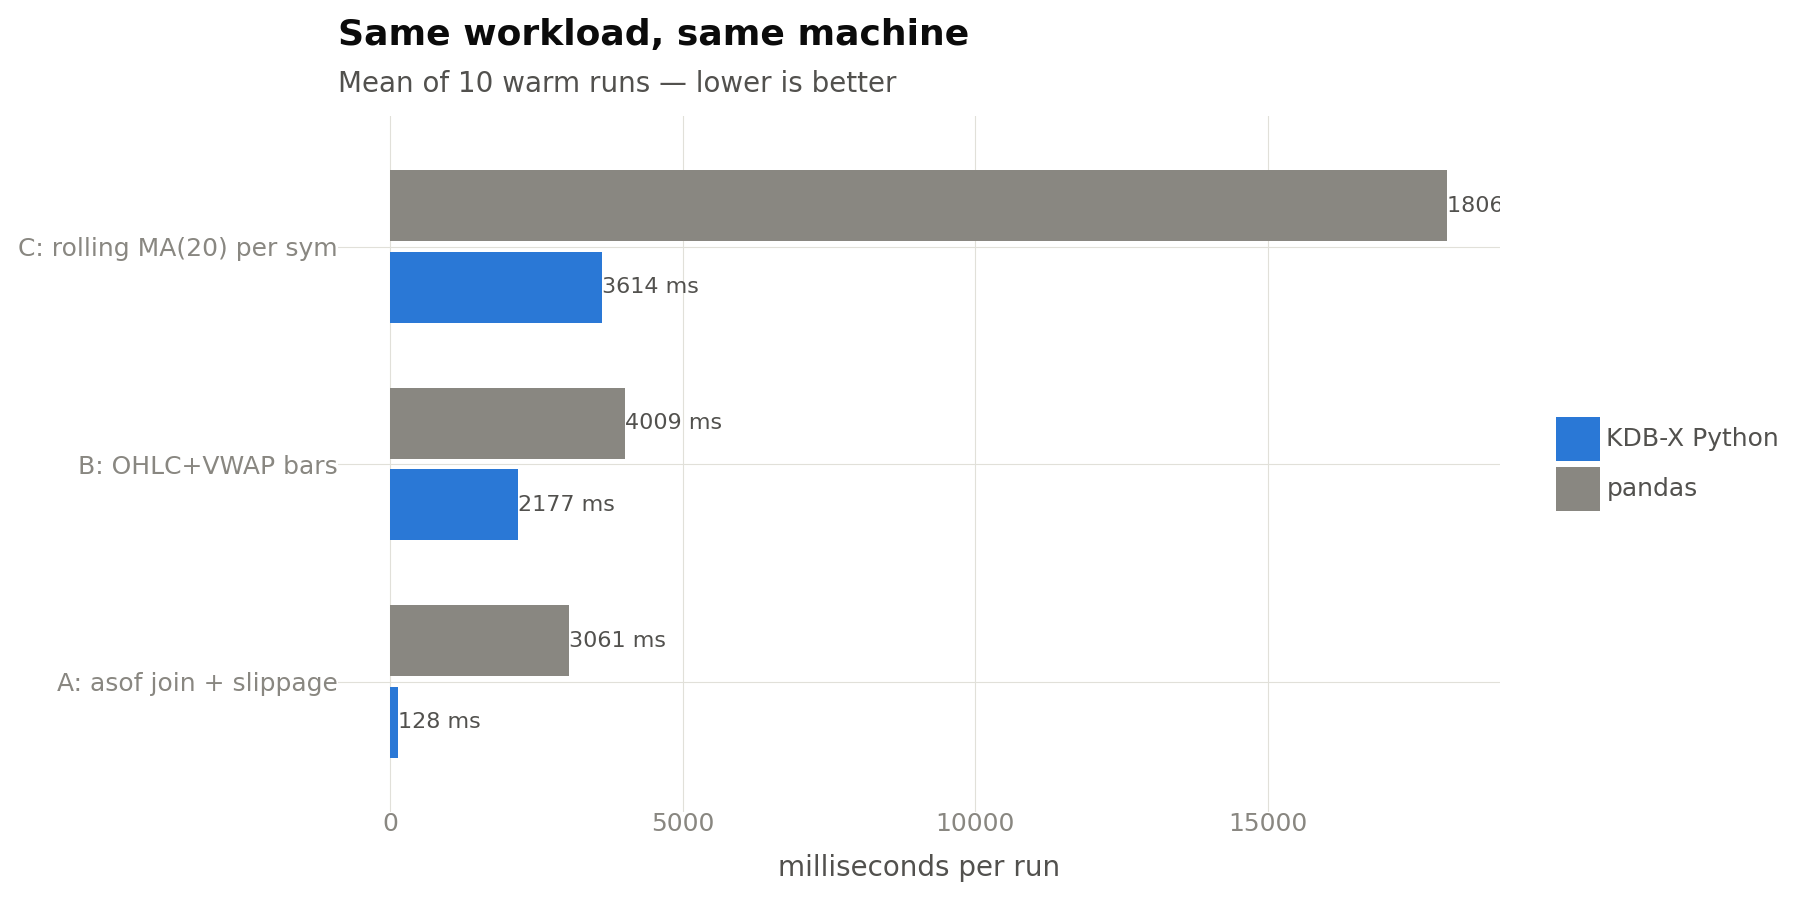

In [42]:
# Section 5 results
chart_df = res_df.copy()
chart_df['ms'] = chart_df['mean_s'] * 1000
chart_df['label'] = chart_df['ms'].round(0).astype(int).astype(str) + ' ms'

(ggplot(chart_df, aes(x='workload', y='ms', fill='engine'))
 + geom_col(position=position_dodge(width=0.75), width=0.65)
 + geom_text(aes(label='label'),
             position=position_dodge(width=0.75),
             ha='left', size=8, color='#52514e')
 + coord_flip()
 + scale_fill_manual(values=ENGINE_COLORS)
 + labs(title='Same workload, same machine',
        subtitle='Mean of 10 warm runs — lower is better',
        x='', y='milliseconds per run')
 + POD_THEME)

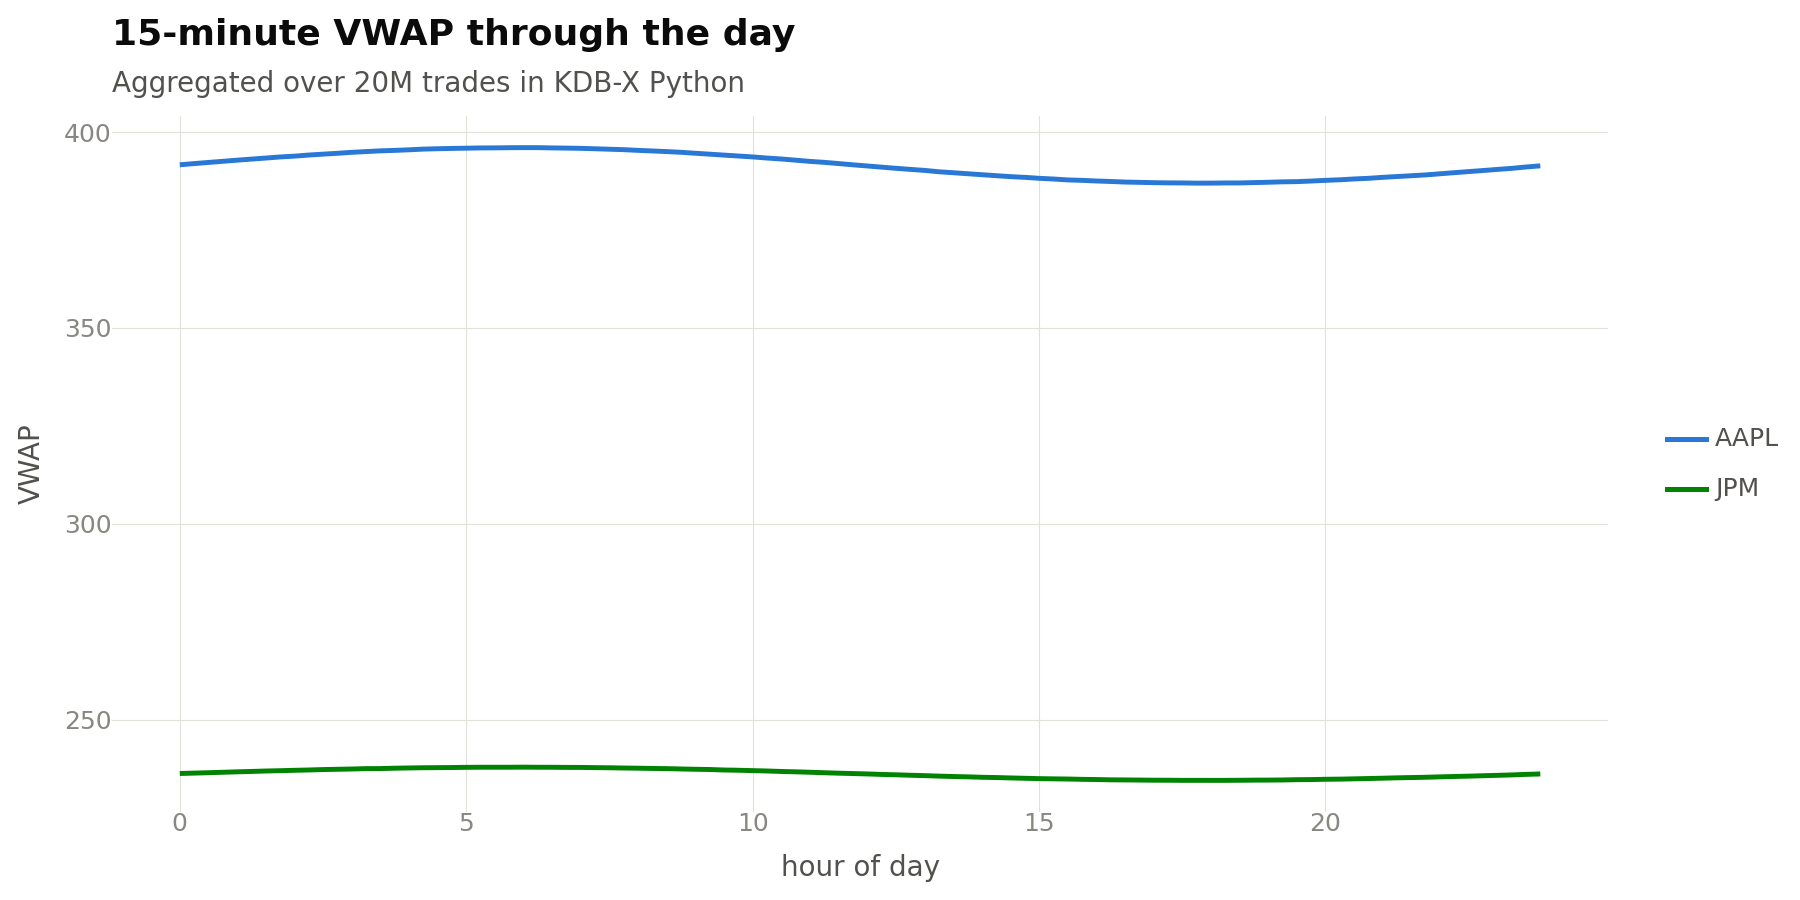

In [43]:
# Intraday VWAP, two symbols, from the Section 3a result
vwap_df = vwap_kx.pd().reset_index()
vwap_df.columns = ['sym', 'bucket', 'vwap']

def to_hours(v):
    s = str(v).split()[-1]
    hh, mm = s.split(':')[:2]
    return int(hh) + int(mm) / 60

vwap_df['hour'] = vwap_df['bucket'].map(to_hours)
two = vwap_df[vwap_df['sym'].isin(['AAPL', 'JPM'])]

(ggplot(two, aes(x='hour', y='vwap', color='sym'))
 + geom_line(size=1)
 + scale_color_manual(values={'AAPL': '#2a78d6', 'JPM': '#008300'})
 + labs(title='15-minute VWAP through the day',
        subtitle='Aggregated over 20M trades in KDB-X Python',
        x='hour of day', y='VWAP')
 + POD_THEME)

### 6b. When you want to see every tick *(optional)*

plotnine plots *results* — aggregates small enough to convert. Raw-tick inspection (bad prints, gaps, microstructure) is where Python plotting taps out, so the [ax module](https://github.com/KxSystems/ax) renders inside the engine instead: skia-rasterized ggplot, no conversion, no downsampling.

In [44]:
# one-time: ax + fusion modules into ~/.kx/mod (~seconds)
import io, platform, ssl, sys, urllib.request, zipfile

_os, _arm = sys.platform, platform.machine().lower() in ('arm64', 'aarch64')
_ax = {'linux': 'ax-l64.zip', 'darwin': 'ax-marm.zip' if _arm else 'ax-mi64.zip',
       'win32': 'ax-w64.zip'}[_os]
_fu = {'linux': 'fusion-l64arm.zip' if _arm else 'fusion-l64.zip',
       'darwin': 'fusion-m64.zip', 'win32': 'fusion-w64.zip'}[_os]

try:                                   # python.org macOS builds ship without CA certs wired up
    import certifi
    _ctx = ssl.create_default_context(cafile=certifi.where())
except ImportError:
    _ctx = ssl.create_default_context()

for name, repo, asset in [('ax', 'ax', _ax), ('fusion', 'fusionx', _fu)]:
    if not (Path.home() / '.kx' / 'mod' / 'kx' / name).exists():
        url = f'https://github.com/KxSystems/{repo}/releases/latest/download/{asset}'
        with urllib.request.urlopen(url, context=_ctx) as r:
            zipfile.ZipFile(io.BytesIO(r.read())).extractall(Path.home() / '.kx' / 'mod')

# kx.module.use can't destructure multi-namespace modules yet — take the dict
qp = kx.q('use `kx.ax.graphics')['qp']
print('ax graphics loaded:', len(qp), 'functions')

ax graphics loaded: 61 functions


500,962 raw ticks rendered
CPU times: user 542 ms, sys: 16.5 ms, total: 559 ms
Wall time: 908 ms


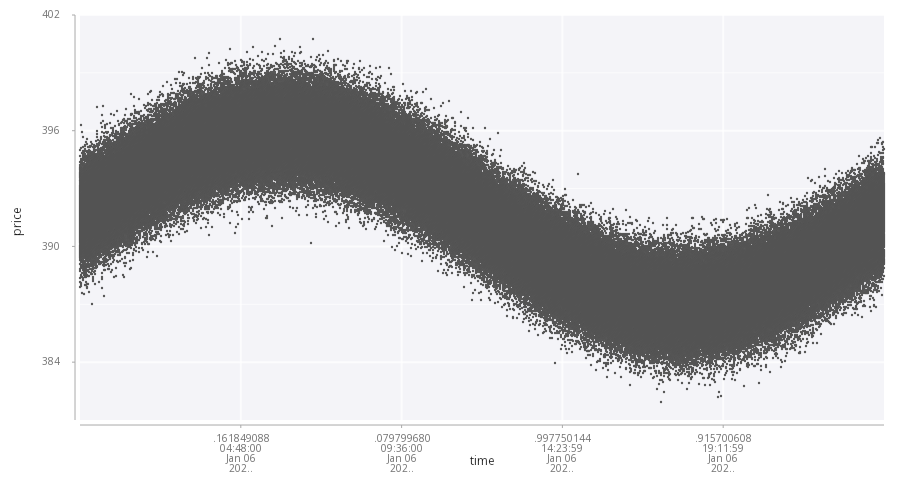

In [45]:
%%time
# every AAPL tick today — no sampling, rendered where the data lives
aapl = trade.select(where=kx.Column('sym') == 'AAPL')

png_file = Path.cwd() / 'research' / 'all_ticks.png'
png_file.parent.mkdir(exist_ok=True)
qp['png'](kx.q.hsym(str(png_file)), 900, 480)(
    qp['point'](aapl, 'time', 'price', None)
)
print(f'{len(aapl):,} raw ticks rendered')

from IPython.display import Image
Image(str(png_file))

---
## 7. Your Parquet files, no import step

KDB-X ships a parquet module (`kx.pq`, bundled with pykx 4). `pq` *maps* a file as a virtual table — row groups load only when a query touches them. Hundreds of files stitch into one partitioned virtual table via `kx.pq.t` ([tutorial](https://github.com/KxSystems/tutorials/blob/main/KDB-X/Modules/parquet.md)).

In [46]:
%%time
# round-trip: write today's trades to parquet, map it back, query in place
import pyarrow.parquet as papq

pq_file = Path.cwd() / 'research' / 'trade_day.parquet'    # beside, never inside, the DB
pq_file.parent.mkdir(exist_ok=True)
papq.write_table(trade.pa(), pq_file)

pq = kx.module.use('kx.pq')     # load the module
vt = pq.pq(Path(pq_file))       # map, not import

# parquet has no symbol type — sym arrives as strings (bytes), so filter via a
# q-side variable
kx.q['tickers'] = [b'AAPL', b'JPM', b'NVDA']

vt.select(
    columns={'vwap': kx.Column('size').wavg(kx.Column('price'))},
    by={'sym': kx.Column('sym')},
    where=kx.Column('sym').isin(kx.Variable('tickers')),
)

CPU times: user 13.3 s, sys: 1.33 s, total: 14.6 s
Wall time: 24.1 s


,vwap
sym,
"""AAPL""",391.4935
"""JPM""",236.1879
"""NVDA""",432.14


The mapped file is a `VirtualTable` — `select` runs against the parquet directly; a materialized result takes the full pandas API. No q anywhere. Many files → one partitioned virtual table via `kx.module.use('kx.pq.t')` ([tutorial](https://github.com/KxSystems/tutorials/blob/main/KDB-X/Modules/parquet.md)).

---
## 8. Connect to your team's kdb

Everything so far ran embedded. Your actual setup: a kdb server that already exists, and a notebook that connects to it. We'll serve Section 4's database from a separate q process — stand-in for your production HDB.

In [47]:
import shutil
import subprocess
import time as _t

# in production this process already exists — you skip straight to the connection
assert shutil.which('q'), 'no q binary on PATH — install KDB-X (developer.kx.com) or point PATH at it'

with kx.PyKXReimport():
    server = subprocess.Popen(
        ['q', str(db_dir), '-p', '5010'],
        stdin=subprocess.PIPE,          # keep stdin open: q exits on EOF
        stdout=subprocess.DEVNULL,
        stderr=subprocess.PIPE,
    )
_t.sleep(3)
if server.poll() is not None:
    raise RuntimeError('q exited: ' + server.stderr.read().decode(errors='replace')[:500])
print('q serving pods_hdb on :5010')

q serving pods_hdb on :5010


In [48]:
%%time
# query the full remote HDB; only the result crosses the wire
try:
    with kx.SyncQConnection('localhost', 5010) as conn:
        res = conn.qsql.select(
            'trade',
            columns={'vwap': kx.Column('size').wavg(kx.Column('price'))},
            by={'date': kx.Column('date'),
                'bucket': kx.Column('time').minute.xbar(15)},
            where=kx.Column('sym') == 'AAPL',
        ).pd()
        # q-string equivalent, if you prefer it:
        # conn('select vwap: size wavg price by date, 15 xbar time.minute from trade where sym=`AAPL')
finally:
    server.kill()

res.head(5)

CPU times: user 154 ms, sys: 27.8 ms, total: 182 ms
Wall time: 229 ms


vwap
date       bucket                     
2025-01-06 0 days 00:00:00  391.647465
           0 days 00:15:00  391.955363
           0 days 00:30:00  392.248981
           0 days 00:45:00  392.534259
           0 days 01:00:00  392.822615

Production is the same three lines with your host: `kx.SyncQConnection('hdb.yourfirm.com', 5010, username=..., password=...)` — TLS via `kx.SecureQConnection`, async via `kx.AsyncQConnection`.

---
## 9. q, when you want it — with an assistant that knows it

Everything above stayed in Python. When you do reach for q — the KX skills for Claude cover it:

```bash
claude plugin marketplace add https://github.com/KxSystems/kx-skills
```

Then install `pykx-knowledge` and `q-knowledge` via `/plugin`. Claude converts pandas to KDB-X Python, writes and lints q (`/qlint-snippet`), and knows every API pattern in this notebook — which was itself built that way.

---
## 10. Get Started

1. `pip install --upgrade pykx` + [free license](https://developer.kx.com/products/kdb-x/install)
2. Point Section 8 at your team's host and port — that's your HDB in this notebook
3. Real data drop-ins: NYSE TAQ files via [taq](https://github.com/KxSystems/taq); realistic synthetic markets via [datagen](https://github.com/KxSystems/datagen)
4. [KDB-X Python docs](https://code.kx.com/pykx/) · [KDB-X tutorials](https://github.com/KxSystems/tutorials)

## Clean Up:

In [49]:
# --- cleanup: remove everything this notebook wrote to disk ---
import shutil
from pathlib import Path

try:
    server.kill()                            # Section 8's q process, if still up
except Exception:
    pass

targets = [
    db_dir,                                  # pods_hdb (~10 GB at DAYS=15)
    db_dir.parent / 'research',              # trade_day.parquet lives here
]
for t in targets:
    t = Path(t)
    if t.is_dir():
        shutil.rmtree(t, ignore_errors=True)
    elif t.is_file():
        t.unlink()
    print(('removed  ' if not t.exists() else 'FAILED   ') + str(t))

removed  /content/pods_hdb
removed  /content/research
